In [1]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

df = df[['survived','pclass','sex','age','fare']]
df = df.dropna()

In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop("survived", axis=1)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [4]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)


In [5]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7552447552447552


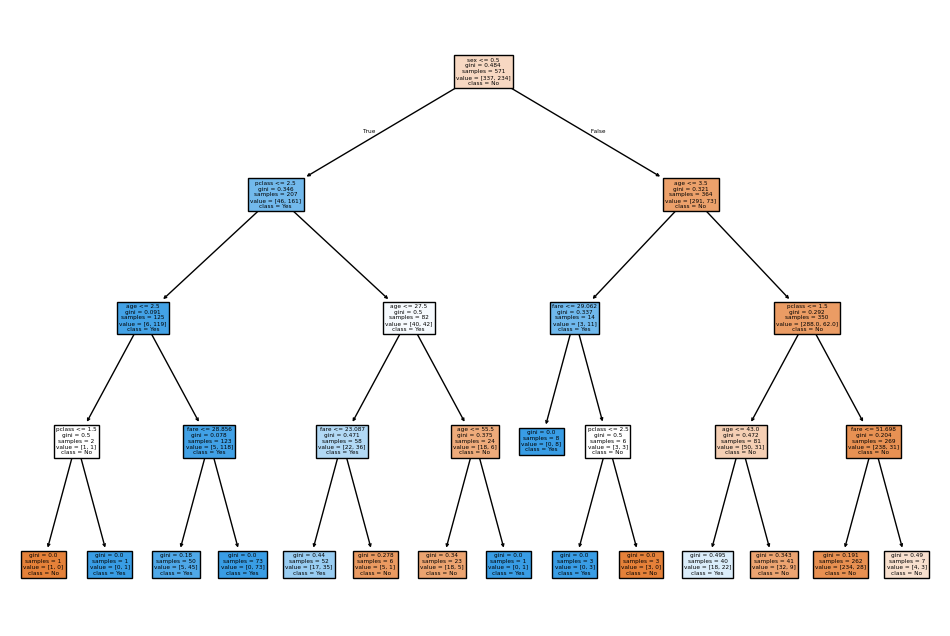

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True
)

plt.show()


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [8]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)


Random Forest Accuracy: 0.7762237762237763


In [9]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

print(importance.sort_values(by="Importance", ascending=False))


  Feature  Importance
2     age    0.320822
1     sex    0.294456
3    fare    0.282083
0  pclass    0.102639


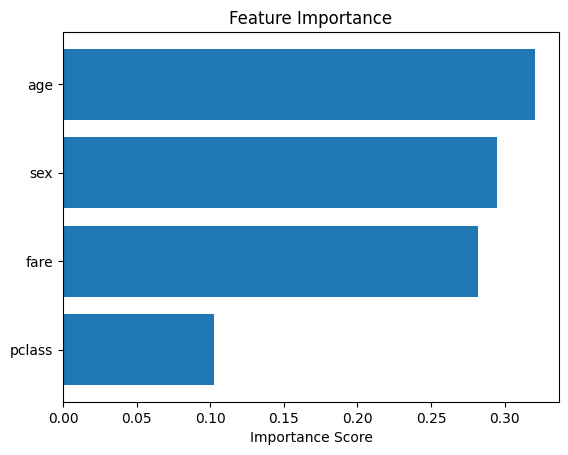

In [10]:
import matplotlib.pyplot as plt

importance = importance.sort_values(by="Importance")

plt.barh(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()


In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[69 18]
 [17 39]]


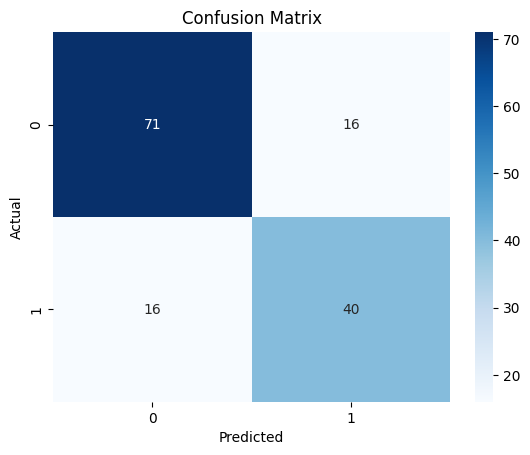

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
